# Notebook to make Figure 13 (Appendix C): Injected vs. MaxL $\cos\theta$ distributions

In [1]:
import numpy as np 
import json 

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import style
style.use('../utils/plotting.mplstyle')
from matplotlib.lines import Line2D

import sys
sys.path.append('../utils')
import plot_utils 

## Setup

Load data

In [2]:
# Predicted vs. Observed PPC traces 
datalevel_predobs = np.load('../data/PPC_traces_data_level.npz', allow_pickle=True)['arr_0'].item()

# True injected values
inj_truths = np.load('../data/injected_truths.npz', allow_pickle=True)['arr_0'].item()

Set up plotting aesthetics, etc.

In [3]:
param='costheta'
xticks = [-1, -.5, 0, .5, 1]

posts = list(datalevel_predobs.keys())

TITLE_FONTSIZE = 30
AXISLABEL_FONTSIZE = 30
TICKLABEL_FONTSIZE = 25
LEGEND_FONTSIZE  = 27

bins=np.linspace(-1,1,25)
hist_kws = dict(density=True, bins=bins)

## Make figure

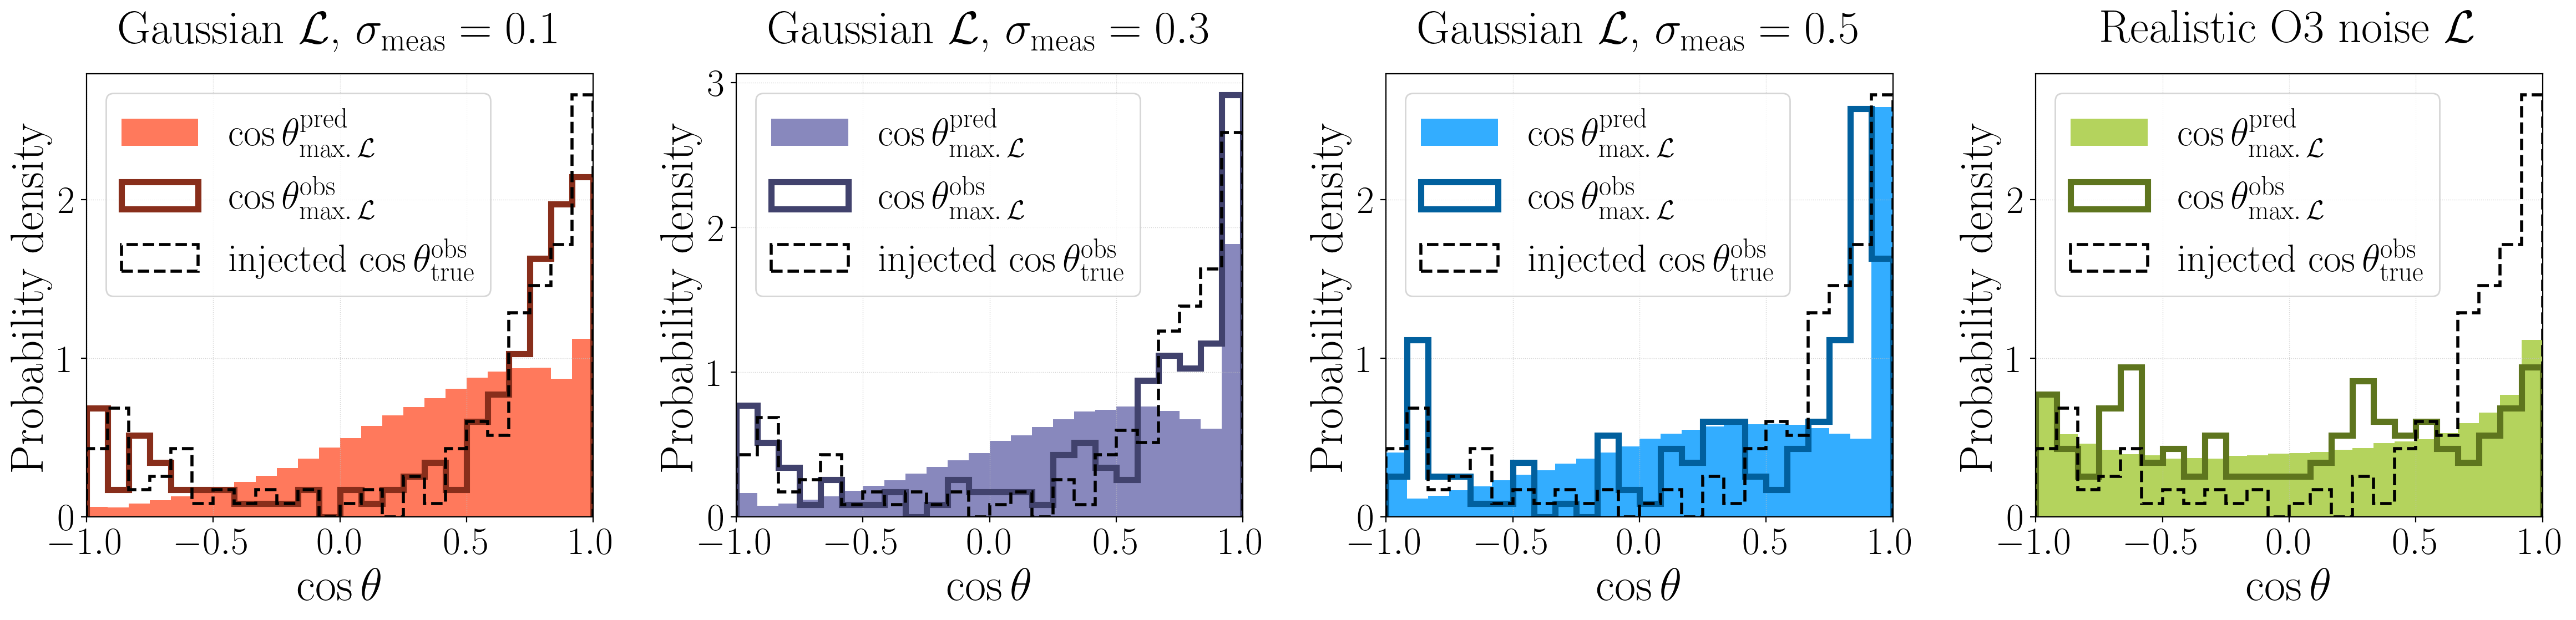

In [4]:
fig, axs = plt.subplots(ncols=4, figsize=(33/1.4, 8/1.4), sharex=True)

for j, post in enumerate(posts):

    # Format axes
    axs[j].set_xlabel(r'$\cos\theta$', fontsize=AXISLABEL_FONTSIZE)
    axs[j].set_ylabel('Probability density', fontsize=AXISLABEL_FONTSIZE)
    axs[j].set_title(plot_utils.run_labels[post], fontsize=TITLE_FONTSIZE, y=1.05)
    axs[j].set_xticks(xticks)
    axs[j].tick_params(axis='both', labelsize=TICKLABEL_FONTSIZE)
    axs[j].set_xlim(-1, 1)
    axs[j].grid()

    # Get data
    pred = datalevel_predobs[post]['predicted'][param].flatten()
    obs = datalevel_predobs[post]['observed'][param].flatten()
    inj = inj_truths[post]

    # Generate histograms
    axs[j].hist(
        pred, **hist_kws, alpha=0.8, color=plot_utils.run_colors[post], 
        label=r'$\cos\theta^{\rm pred}_{\rm max.\,\mathcal L}$'
    )
    axs[j].hist(
        obs, **hist_kws, histtype='step', lw=4, color=plot_utils.run_colors_darker[post], 
        label=r'$\cos\theta^{\rm obs}_{\rm max.\,\mathcal L}$'
    )
    axs[j].hist(
        inj, **hist_kws, histtype='step', lw=2, color='k', ls='--', 
        label=r'injected $\cos\theta^{\rm obs}_{\rm true}$'
    )

    # Add legend
    axs[j].legend(fontsize=25)

plt.tight_layout()
plt.savefig('figure_13.png', dpi=300, bbox_inches='tight')
plt.show()